# Compound Clustering Tutorial

Clustering molecules is not just a way to **group similar compounds**; it plays an important role in several real-world scenarios in cheminformatics:

- **Exploratory Data Analysis**: Helps to understand the diversity of the dataset and allows for the identification of representative scaffolds.
- **Cross-Validation Strategies**: In predictive modeling, standard random train/test splits may lead to **data leakage**, where very similar molecules appear in both training and test sets. Clustering-based splitting ensures that similar compounds remain in the same fold, leading to a more realistic evaluation of model generalization.
- **Chemical Library Design**: Selecting diverse representatives from clusters to build smaller, balanced subsets for screening campaigns helps avoid redundancy in compound libraries and **exclude near duplicates**.

In this tutorial, we'll focus solely on the **clustering methods** available in the MOTHER framework. Keep in mind that the same workflow can be directly fed into a **cross-validation pipeline** or used for **diversity analysis** in real projects.


In [1]:
import polaris as po
from IPython.display import SVG, display
import logging
from pathlib import Path
import pandas as pd
from rdkit.Chem import Draw, rdDepictor
import polaris as po
from sklearn import pipeline as sklearn_pipeline
from mother import cv as cv_module
from mother import feature_generation as fg
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer
from mother.cv.report.cluster import visualize_scaffolds
import numpy as np

logging.basicConfig(level=logging.INFO)

In [2]:
# helper functions
def visualize_cluster(df, cluster_col, cluster_id, sort_by=None, n=36, mols_per_row=6):
    rdDepictor.SetPreferCoordGen(True)
    sub = df[df[cluster_col] == cluster_id].copy()
    if sort_by is not None and sort_by in sub.columns:
        sub = sub.sort_values(sort_by)
    sub = sub.head(n)

    mols = list(sub["Molecule"])
    legends = [
        f"{cluster_col}={cluster_id} | expt={x:.3g}" if "expt" in sub else f"{cluster_col}={cluster_id}"
        for x in sub.get("expt", np.repeat(float("nan"), len(sub)))
    ]

    img = Draw.MolsToGridImage(mols, legends=legends, molsPerRow=mols_per_row, subImgSize=(220, 180), useSVG=True)
    display(SVG(img.data))
    return sub

## Import Data

We start with a dataset containing the following columns:

- **`SMILES`**: This column contains molecular structure representations in **SMILES** format.
- **`"LOG_HLM_CLint", "LOG_RLM_CLint"`**: These columns hold the experimental values, which serve as our target variables.

In [3]:
dataset = po.load_dataset("biogen/adme-fang-v1")
dataset.size()

data = dataset.table
data.head()

data = data[["SMILES", "LOG_HLM_CLint", "LOG_RLM_CLint"]]

Output()

INFO:httpx:HTTP Request: GET https://polarishub.io/api/v1/dataset/biogen/adme-fang-v1 "HTTP/1.1 200 OK"


[2025-10-21 11:55:09] INFO     The version of Polaris that was used to create the artifact (dev) is ]8;id=181379;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/_artifact.py\_artifact.py]8;;\:]8;id=8763;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/_artifact.py#96\96]8;;\
                               different from the currently installed version of Polaris (0.13.0).                 

INFO:polaris._artifact:The version of Polaris that was used to create the artifact (dev) is different from the currently installed version of Polaris (0.13.0).


                      INFO     To verify the checksum, we need to recompute it. This can be slow    ]8;id=351769;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/mixins/_checksum.py\_checksum.py]8;;\:]8;id=1504;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/mixins/_checksum.py#67\67]8;;\
                               for large datasets.                                                                 

INFO:polaris.mixins._checksum:To verify the checksum, we need to recompute it. This can be slow for large datasets.


[11:55:09]  Success: Fetching dataset                                                                 ]8;id=770625;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/utils/context.py\context.py]8;;\:]8;id=150612;file:///workspaces/mother-ml/.venv/lib/python3.11/site-packages/polaris/utils/context.py#53\53]8;;\

## Preprocessing

Preprocessing consists of two main steps:

1. **Standardization**: This step involves cleaning up the SMILES representations to generate consistent molecular structures.
2. **SMILES-to-Molecule Conversion**: In this step, we convert text-based SMILES into RDKit molecule objects.

In [4]:
# Define preprocessing pipeline

preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(
                flags=[
                    "STANDARDIZE",
                    "NEUTRALIZE",
                    "DESALT",
                ]
            ),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
    ],
    memory=None,
).set_output(transform="pandas")

# Apply to dataset
structure_data: pd.Series = data["SMILES"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[11:55:21] Initializing Normalizer
[11:55:21] Initializing Normalizer
[11:55:21] Initializing MetalDisconnector
[11:55:21] Initializing Normalizer
ERROR:mother.preprocessing.core:Catched exception
Traceback (most recent call last):
  File "/workspaces/mother-ml/mother/preprocessing/core.py", line 71, in _transform
    with m_chem.RaiseRDKitErrors():
  File "/workspaces/mother-ml/mother/chem.py", line 104, in __exit__
    raise RDKitException(self.clean_error_msg(stderr))
mother.chem.RDKitException: Running MetalDisconnector Running FragmentRemover Running LargestFragmentChooser Running Uncharger Running Normalizer Can't kekulize mol.  Unkekulized atoms: 3 5 FAILED sanitizeMol.
ERROR:mother.preprocessing.core:Catched exception
Traceback (most recent call last):
  File "/workspaces/mother-ml/mother/preprocessing/core.py", line 71, in _transform
    with m_chem.RaiseRDKitErrors():
  Fil

## Feature Generation

Next, we compute **molecular fingerprints**, which represent molecules as bit vectors. In this tutorial, we will utilize **Morgan fingerprints**, a widely used circular fingerprinting method known for its effectiveness in capturing molecular features.

In [5]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[("morgan", fg.MorganFingerprints())],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


## Combine Data

We will now combine the following components into a single DataFrame for clustering:

- **Fingerprint Features**: The molecular fingerprints generated in the previous step.
- **RDKit Molecule Objects**: The RDKit representations of the molecules.
- **Experimental Values (`expt`)**: The target variable containing experimental data.

This consolidated DataFrame will serve as the input for our clustering analysis.

In [6]:
df = pd.concat([features, mol_data, data["LOG_HLM_CLint"]], axis=1)

## Clustering Approaches 

We explore three clustering strategies:

| **Clustering Strategy** | **Accessible via**                             | **Description**                                                                                          |
|-------------------------|------------------------------------------------|----------------------------------------------------------------------------------------------------------|
| `KMedoids`              | `cv_module.KMedoidsGroupingFromMols`         | Partitions data into K clusters, using actual molecules as cluster centers (medoids).                   |
| `HDBSCAN`               | `cv_module.HdbscanGroupingFromMols`           | A density-based clustering method that can discover clusters of arbitrary shape and detect noise points. |
| `Tanimoto`              | `cv_module.TanimotoGroupingFromMols`          | Groups molecules based on Tanimoto similarity with a specified threshold cutoff.                          |

### Parameters

All methods utilize fingerprint similarity. The key tunable parameters are:

- **radius** (default = 2)
- **fp_size** (default = 2048)
- **include_chirality** (default = True)

### Tanimoto Sphere Exclusion Clustering 

Tanimoto Sphere Exclusion Clustering is widely used in cheminformatics due to its:

- **Speed and Scalability**: The method is efficient, allowing for rapid clustering of large datasets.
- **Threshold Control**: Users can explicitly define the chemical similarity required within a cluster by setting a similarity threshold, providing greater control over the clustering process.

In [7]:
# Initialize clustering engine
generation_engine = cv_module.TanimotoGroupingFromMols(
    similarity_threshold=0.6, radius=2, fp_size=2048, include_chirality=True
)

# Apply clustering and visualize the outcome
clusters = generation_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])
df = pd.concat([df, clusters], axis=1)
df.head()

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.6
INFO:mother.cv.cv_methods:Found: 3167 clusters


,morgan__MorganFP_0,morgan__MorganFP_1,morgan__MorganFP_2,morgan__MorganFP_3,morgan__MorganFP_4,morgan__MorganFP_5,morgan__MorganFP_6,morgan__MorganFP_7,morgan__MorganFP_8,morgan__MorganFP_9,...,morgan__MorganFP_1017,morgan__MorganFP_1018,morgan__MorganFP_1019,morgan__MorganFP_1020,morgan__MorganFP_1021,morgan__MorganFP_1022,morgan__MorganFP_1023,Molecule,LOG_HLM_CLint,tanimoto-group
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435e570>,0.886265,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435c040>,0.675687,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435e880>,2.081607,2.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435ef80>,NaN,3.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435dd90>,1.888410,4.0


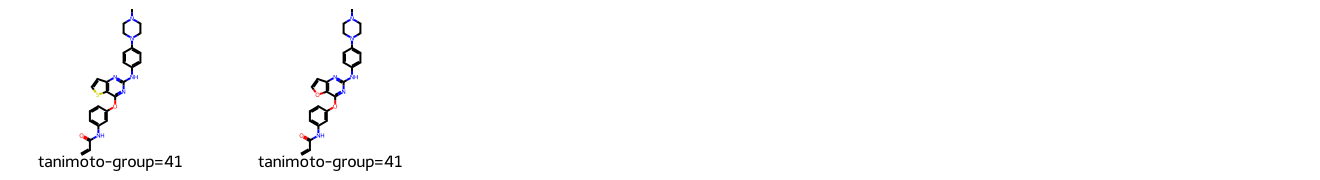

,morgan__MorganFP_0,morgan__MorganFP_1,morgan__MorganFP_2,morgan__MorganFP_3,morgan__MorganFP_4,morgan__MorganFP_5,morgan__MorganFP_6,morgan__MorganFP_7,morgan__MorganFP_8,morgan__MorganFP_9,...,morgan__MorganFP_1019,morgan__MorganFP_1020,morgan__MorganFP_1021,morgan__MorganFP_1022,morgan__MorganFP_1023,Molecule,LOG_HLM_CLint,tanimoto-group,hdbscan_clusters,kmedoids_clusters
45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e24370040>,0.990827,41.0,75.0,0.0
44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435db60>,1.209408,41.0,75.0,0.0


In [20]:
visualize_cluster(df, cluster_col="tanimoto-group", cluster_id=41, sort_by="LOG_HLM_CLint", n=36, mols_per_row=6)

### HDBSCAN Clustering

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) offers several advantages:

- **Density-Based**: Unlike K-Means, HDBSCAN does not assume spherical clusters and can find clusters of arbitrary shapes.
- **Automatic Cluster Selection**: There is no need to pre-specify the number of clusters, making it more flexible than K-Means.
- **Noise Handling**: Molecules that do not clearly belong to any cluster are marked as noise instead of being forced into a group.
- **Meaningful Clusters**: Since our implementation is based on molecular fingerprints and scaffolds, the resulting clusters often correspond to meaningful chemical classes.

#### Unique Aspect: Scaffold-Based Clustering

This implementation incorporates **Murcko scaffolding**, a concept that reduces a molecule to its core scaffold by removing side chains. This allows for scaffold-level grouping rather than merely similarity-based grouping. You can control how scaffolds are defined using the following options:

- **`scaffold = 'Murco'`**: This setting uses the standard Murcko scaffold, retaining atom types and bond types.
- **`scaffold = 'GenericMurcko'`**: This option uses a generic Murcko scaffold, where all atoms are converted to carbons and all bonds are simplified to single bonds.

This snippet demonstrates how to apply HDBSCAN clustering to our dataset of interest. These settings help tailor the clustering process to effectively capture the chemical diversity within the dataset.

In [9]:
from mother.cv import core

column_name = "hdbscan_clusters"

hdbscan_engine = core.HdbscanGroupingFromMols(
    scaffold="Murcko", radius=2, fp_size=2048, include_chirality=True, min_cluster_size=5
)
df[column_name] = hdbscan_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying HDBSCAN clustering to the dataset
INFO:mother.cv.cv_methods:HDBSCAN clustering grouped data into 141 groups
INFO:mother.cv.report.cluster:Average Silhouette Score: -0.0070


HDBSCAN assigns a unique integer label to each cluster it identifies based on the density of data points in the feature space. The labels are typically positive integers starting from **0**.
Points that do not belong to any cluster are considered **noise**, indicating that they are not sufficiently close to any dense regions (clusters) associated with them.

The label **-1** serves as a special designation in HDBSCAN, specifically identifying these noise points.

In [10]:
df

,morgan__MorganFP_0,morgan__MorganFP_1,morgan__MorganFP_2,morgan__MorganFP_3,morgan__MorganFP_4,morgan__MorganFP_5,morgan__MorganFP_6,morgan__MorganFP_7,morgan__MorganFP_8,morgan__MorganFP_9,...,morgan__MorganFP_1018,morgan__MorganFP_1019,morgan__MorganFP_1020,morgan__MorganFP_1021,morgan__MorganFP_1022,morgan__MorganFP_1023,Molecule,LOG_HLM_CLint,tanimoto-group,hdbscan_clusters
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435e570>,0.886265,0.0,-1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435c040>,0.675687,1.0,59.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435e880>,2.081607,2.0,109.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435ef80>,NaN,3.0,51.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435dd90>,1.888410,4.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3516,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241df4c0>,0.920801,3163.0,49.0
3517,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241df530>,1.240899,215.0,-1.0
3518,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241df5a0>,1.964066,3164.0,-1.0
3519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241df610>,1.985754,3165.0,-1.0


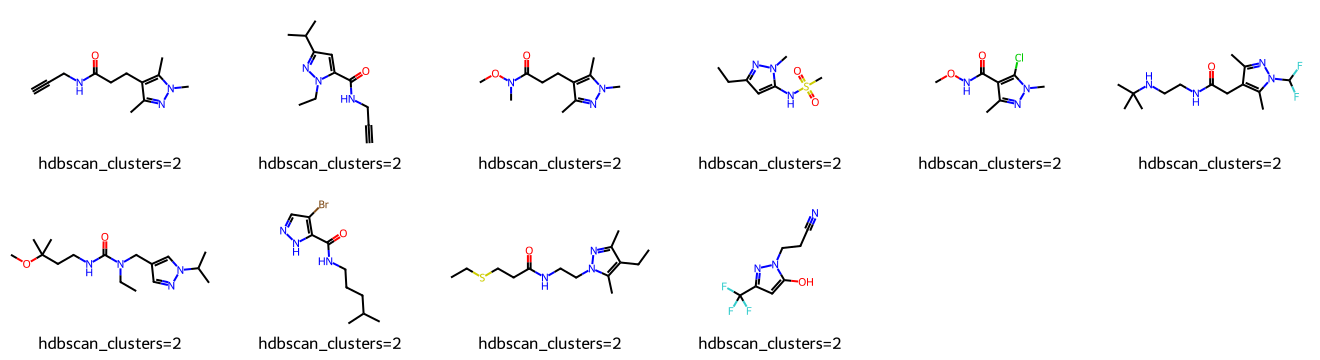

,morgan__MorganFP_0,morgan__MorganFP_1,morgan__MorganFP_2,morgan__MorganFP_3,morgan__MorganFP_4,morgan__MorganFP_5,morgan__MorganFP_6,morgan__MorganFP_7,morgan__MorganFP_8,morgan__MorganFP_9,...,morgan__MorganFP_1019,morgan__MorganFP_1020,morgan__MorganFP_1021,morgan__MorganFP_1022,morgan__MorganFP_1023,Molecule,LOG_HLM_CLint,tanimoto-group,hdbscan_clusters,kmedoids_clusters
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435e5e0>,0.675687,9.0,2.0,1.0
15,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2435c660>,0.675687,15.0,2.0,1.0
1222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2439c0b0>,0.675687,1133.0,2.0,1.0
748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2438ef10>,0.675687,698.0,2.0,1.0
1227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2439c2e0>,0.675687,1138.0,2.0,1.0
2402,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e243bc970>,0.675687,2191.0,2.0,1.0
591,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2438a9d0>,0.751587,550.0,2.0,1.0
242,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e24381700>,1.217957,225.0,2.0,1.0
721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2438e340>,2.164974,674.0,2.0,1.0
2681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241c84a0>,NaN,2456.0,2.0,1.0


In [17]:
visualize_cluster(df, cluster_col="hdbscan_clusters", cluster_id=2, sort_by="LOG_HLM_CLint", n=36, mols_per_row=6)

### PAM K-Medoids Clustering

The implementation of K-Medoids with PAM clustering offers several notable features:

- **Medoids as Real Molecules**: This approach uses actual molecules as medoids, which can facilitate the interpretability of the results.
- **Robustness to Outliers**: PAM clustering minimizes total pairwise dissimilarity to medoids, making it more stable than K-Means, especially when dealing with noisy compounds or uneven density.
- **Jaccard Distance Metric**: It utilizes a distance metric specifically designed for handling binary data, enhancing its effectiveness with molecular fingerprints.
- **Scaffold-Level Control**: The `scaffold` parameter allows users to decide whether clusters should reflect chemical information.

#### Practical Notes

- **Parameter `clusters_number`**: This parameter must be specified. Common methods for determining the optimal number of clusters include:
  - Inspecting the Silhouette score
  - Identifying the elbow point in within-cluster dissimilarity
  - Evaluating cluster stability across random seeds
  - Selecting a value of k that aligns well with project needs

This snippet partitions molecules into **k scaffold-aware groups** using PAM K-Medoids, ensuring that each cluster is summarized by real, representative molecules.

In [12]:
kmedoids_clusters = pd.DataFrame(index=mol_data.index)
column_name = "kmedoids_clusters"

kmedoids_engine = core.KMedoidsGroupingFromMols(
    scaffold="Murcko",
    clusters_number=5,
    radius=2,
    fp_size=2048,
    include_chirality=True,
    iteration_method="random",
    max_iter=100,
    random_state=42,
)
df[column_name] = kmedoids_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying PAM k-medoids clustering to create 5 clusters
INFO:mother.cv.report.cluster:Average Silhouette Score: 0.0348
INFO:mother.cv.cv_methods:PAM k-medoids clustering grouped data into 5 clusters


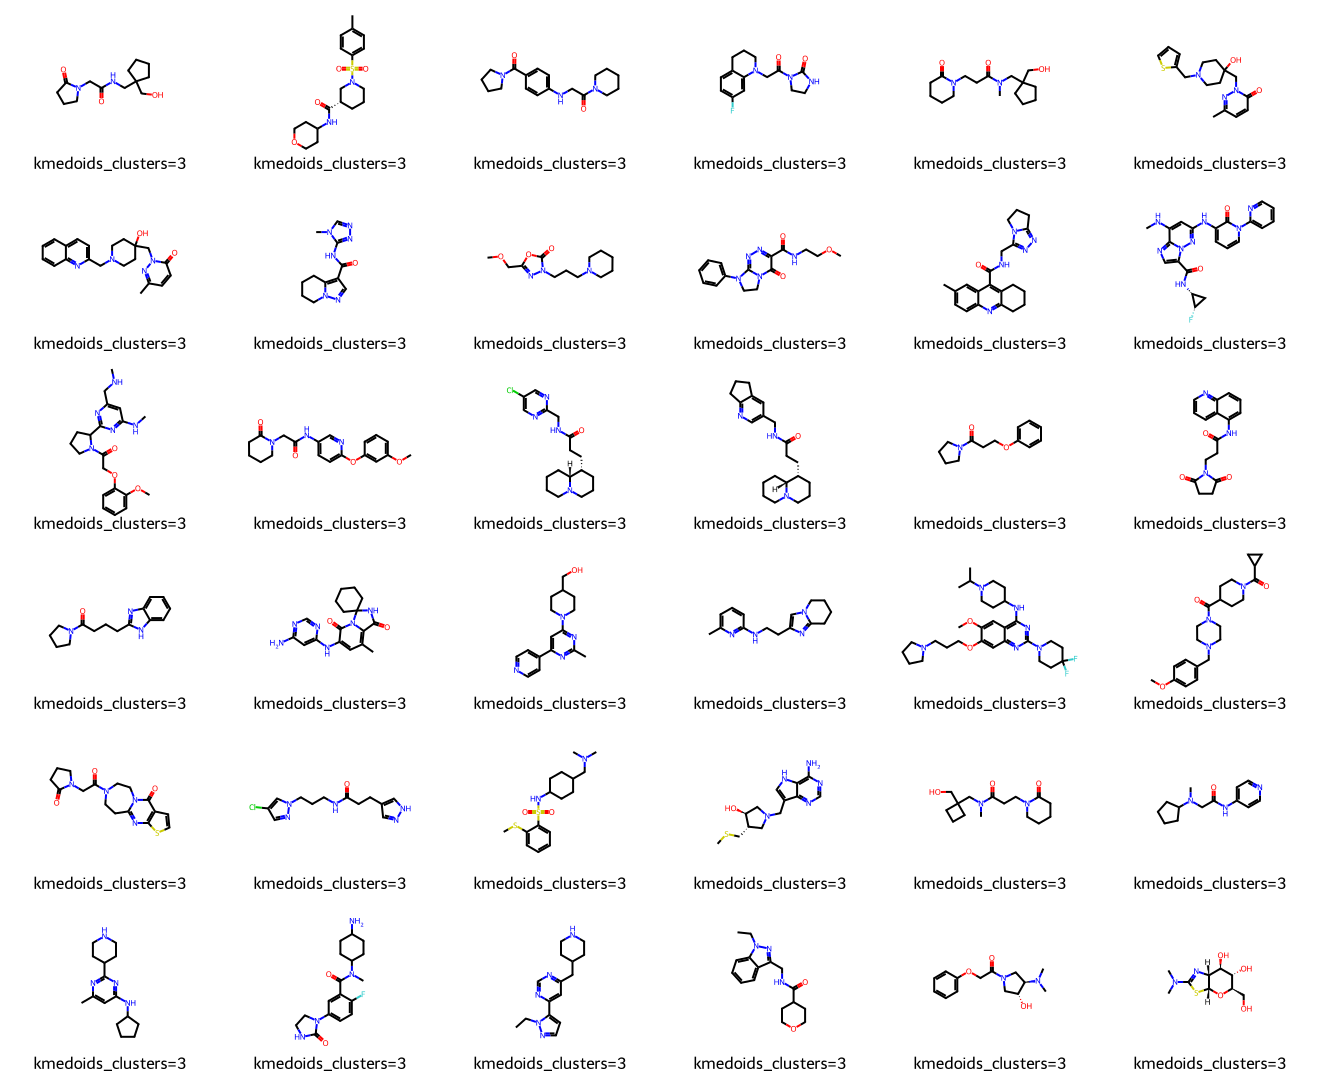

,morgan__MorganFP_0,morgan__MorganFP_1,morgan__MorganFP_2,morgan__MorganFP_3,morgan__MorganFP_4,morgan__MorganFP_5,morgan__MorganFP_6,morgan__MorganFP_7,morgan__MorganFP_8,morgan__MorganFP_9,...,morgan__MorganFP_1019,morgan__MorganFP_1020,morgan__MorganFP_1021,morgan__MorganFP_1022,morgan__MorganFP_1023,Molecule,LOG_HLM_CLint,tanimoto-group,hdbscan_clusters,kmedoids_clusters
2953,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241cfc30>,0.675687,2693.0,47.0,3.0
2043,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e243b2ab0>,0.675687,1869.0,104.0,3.0
2968,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241d0350>,0.675687,2703.0,-1.0,3.0
2959,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e241cfed0>,0.675687,2695.0,-1.0,3.0
942,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e24394510>,0.675687,881.0,47.0,3.0
1929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e243af840>,0.675687,1768.0,-1.0,3.0
1928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e243af7d0>,0.675687,1768.0,-1.0,3.0
2608,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e243c2420>,0.675687,2388.0,-1.0,3.0
1219,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2439bed0>,0.675687,495.0,-1.0,3.0
1190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x7a5e2439b220>,0.675687,1105.0,5.0,3.0


In [19]:
visualize_cluster(df, cluster_col="kmedoids_clusters", cluster_id=3, sort_by="LOG_HLM_CLint", n=36, mols_per_row=6)

In [14]:
murcko_scaffolds = kmedoids_engine.get_murcko_scaffolds_out()

/workspaces/mother-ml/.venv/lib/python3.11/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


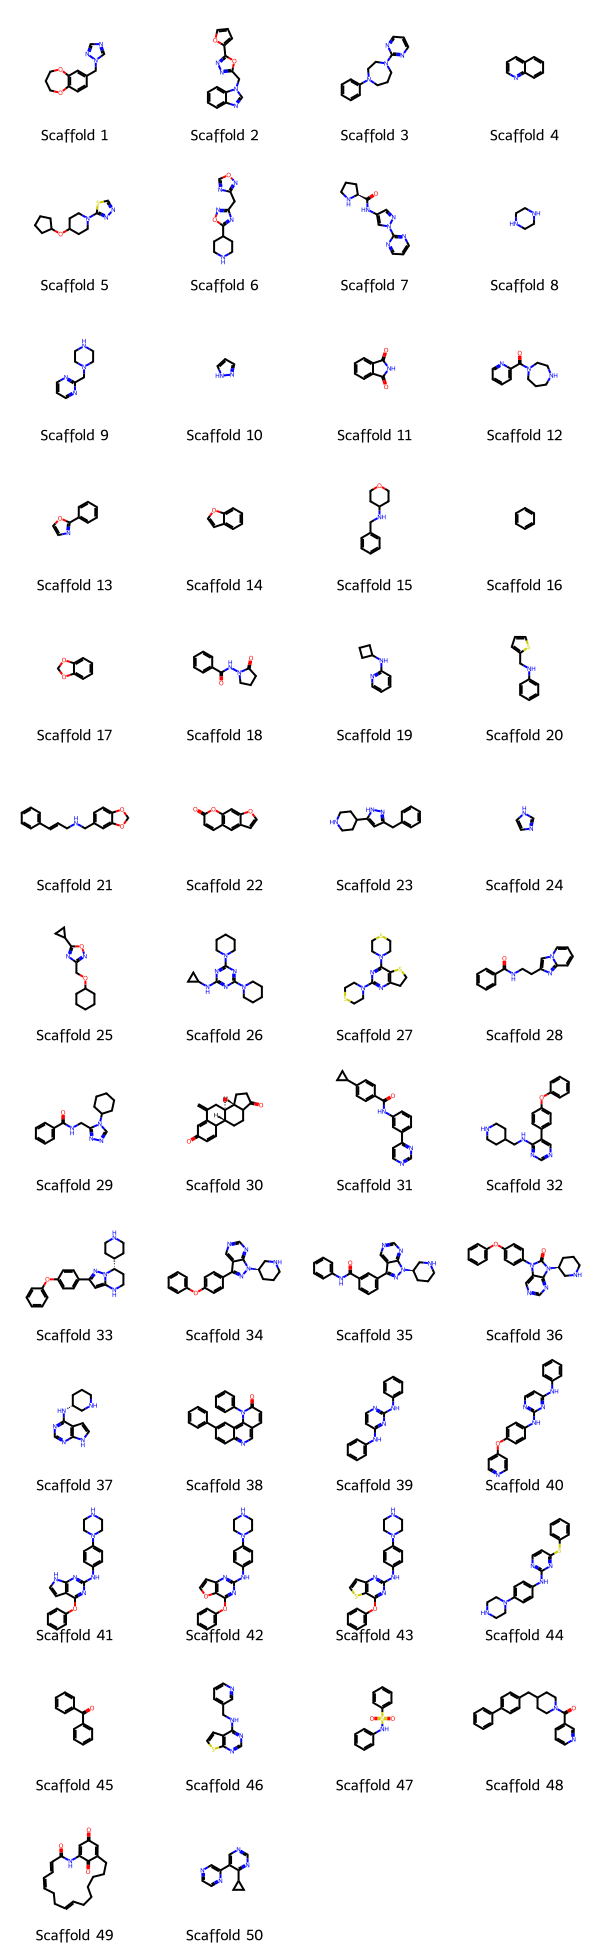

In [15]:
visualize_scaffolds(murcko_scaffolds, max_mols=600)